<a href="https://colab.research.google.com/github/shivanshu-web/Bootcamp/blob/main/Bootcamp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks) - 1):
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")

print("Average:", average)

Class failed
Average: 43.0


In [3]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [4]:
df.shape

(6, 5)

In [5]:
df.head()

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [7]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [8]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [9]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [10]:
eligible_students = df[df["eligible"] == True]
eligible_students

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


Normalizing scores and applying custom weights (30% Assignment, 70% Quiz)

In [11]:
df['total_score'] = (df['assignment_score'] / 20 * 30) + (df['quiz_score'] / 100 * 70)

Criteria for exam/passing eligibility

In [12]:
df['eligible_for_exam'] = (df['attendance_percent'] >= 75) & (df['lab_completed'] == True)

In [13]:
# Identify students requiring immediate intervention
at_risk = df[(df['attendance_percent'] < 70) | (df['lab_completed'] == False)]

print("--- At-Risk Students requiring attention ---")
print(at_risk[['student_id', 'attendance_percent', 'lab_completed']])

--- At-Risk Students requiring attention ---
   student_id  attendance_percent  lab_completed
1         102                  67          False
3         104                  45          False


In [14]:
# Group data to see how completing labs affects academic performance
lab_impact = df.groupby('lab_completed')[['attendance_percent', 'assignment_score', 'quiz_score', 'total_score']].mean()

print("--- Performance Averages Grouped By Lab Status ---")
print(lab_impact)

--- Performance Averages Grouped By Lab Status ---
               attendance_percent  assignment_score  quiz_score  total_score
lab_completed                                                               
False                       56.00              10.0        39.0        42.30
True                        83.75              16.5        68.0        72.35


/tmp/ipykernel_12606/1528551683.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='student_id', y='total_score', palette='viridis')


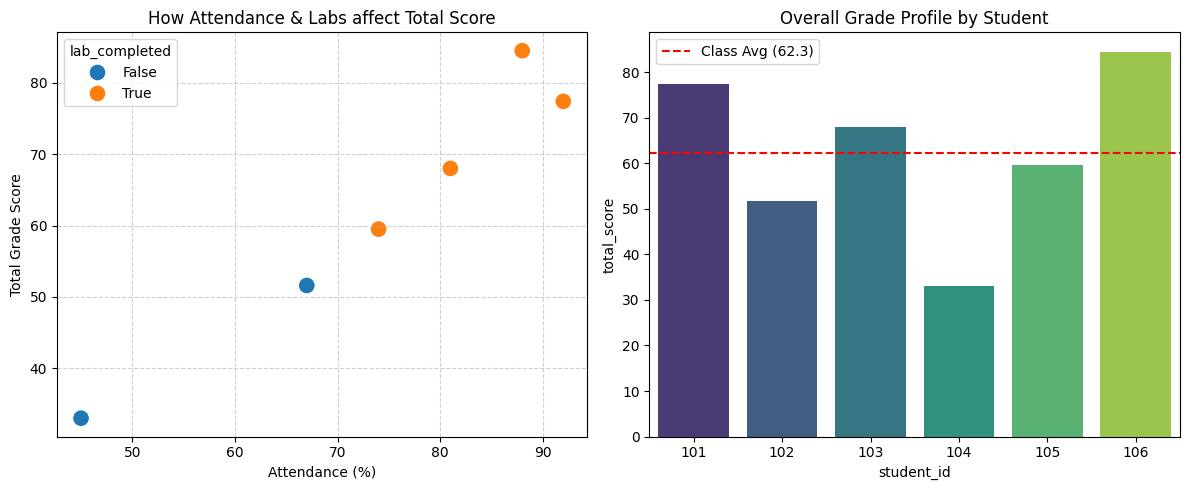

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Plot 1: Trend analysis comparing Attendance vs Final Grade
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='attendance_percent', y='total_score', hue='lab_completed', s=150)
plt.title('How Attendance & Labs affect Total Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Total Grade Score')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Total scores across individual student IDs
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='student_id', y='total_score', palette='viridis')
plt.axhline(df['total_score'].mean(), color='red', linestyle='--', label=f"Class Avg ({df['total_score'].mean():.1f})")
plt.title('Overall Grade Profile by Student')
plt.legend()

plt.tight_layout()
plt.show()